## Imports

In [16]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style.
# TODO(gp): Is this needed?
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import helpers.hmodule as hmodule

hmodule.install_module_if_not_present(
    "networkx",
    use_activate=True,
)
hmodule.install_module_if_not_present(
    "pgmpy",
    use_activate=True,
)

pymc is not installed
arviz is not installed
preliz is not installed
sns is not installed


Python 3.12.13
Linux 9c90f436bfab 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 GNU/Linux


In [ ]:
import msml610_utils as ut
import L08_04_02_causal_inference_utils as mtl0cireout

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

In [3]:
import networkx as nx

import pgmpy.base as pgmpy_base

# Cell 1: Causal Roles Explorer

**Goal**:
- Visualize which nodes in a DAG play the role of confounders, mediators, or
  colliders relative to a selected treatment-outcome pair
- Build intuition for how graph structure determines causal relationships

**Plots**:
- A DAG with nodes color-coded by their causal role:
  - _Treatment_: green
  - _Outcome_: blue
  - _Confounders_: orange (common ancestors of treatment and outcome)
  - _Mediators_: purple (on a directed path from treatment to outcome)
  - _Colliders_: red (receives arrows from both neighbors on some path)
  - _Other_: light blue

**Parameters**:
- `Graph`: select a predefined causal graph (Confounder, Mediator, Collider,
  etc.)
- `Treatment`: the treatment node
- `Outcome`: the outcome node

**Key observations**:
- The same node can play different roles depending on the treatment-outcome pair
- Conditioning on a collider opens a previously closed path (collider bias)
- Conditioning on a mediator blocks the causal path from treatment to outcome

In [4]:
# Display interactive causal roles explorer: select a graph, treatment, and
# outcome to highlight confounders, mediators, and colliders.
mtl0cireout.cell1_causal_roles_explorer()

# Cell 2: D-Separation Graph Analysis

- Build a specific DAG and manually query d-separation properties
- Demonstrate how conditioning on a node can open or close paths between nodes

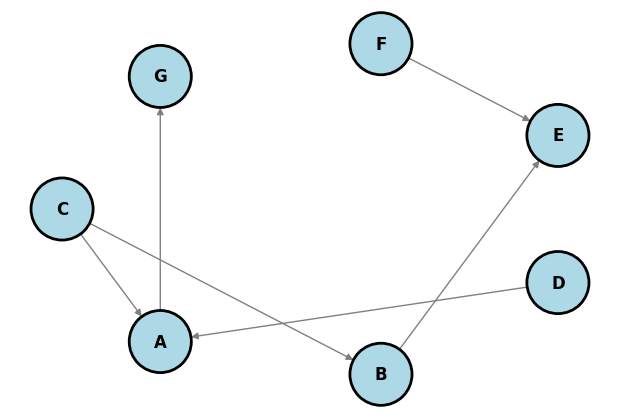

In [5]:
model = nx.DiGraph(
    [
        ("C", "A"),
        ("C", "B"),
        ("D", "A"),
        ("B", "E"),
        ("F", "E"),
        ("A", "G"),
    ]
)

mtl0cireout.plot_graph_highlight(model)

In [6]:
# Convert your NetworkX graph to pgmpy DAG.
dag = pgmpy_base.DAG(model.edges())

print("Are D and C dependent?")
print(not dag.is_dconnected("D", "C"))

Are D and C dependent?
True


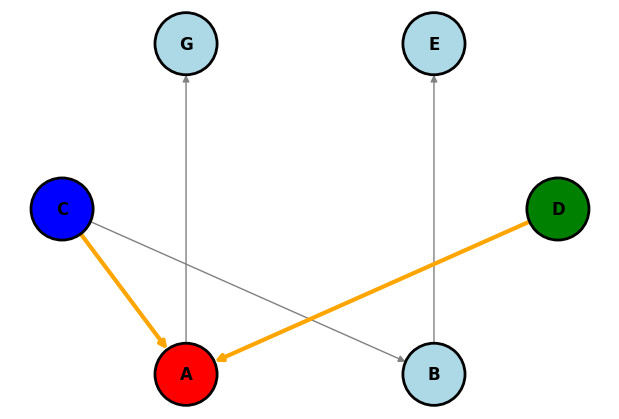

In [7]:
subgraph = mtl0cireout.reachable_subgraph(model, ["A", "D", "C"])
mtl0cireout.plot_graph_highlight(
    subgraph,
    node1="D",
    node2="C",
    conditioning_node_set=["A"],
)

In [8]:
print("Are D and C dependent given A?")
print(not dag.is_dconnected("D", "C", observed={"A"}))

Are D and C dependent given A?
False


In [9]:
print("Are D and C dependent given G?")
print(not dag.is_dconnected("D", "C", observed={"G"}))

Are D and C dependent given G?
False


In [10]:
print("Are G and D dependent?")
print(not dag.is_dconnected("G", "D"))

Are G and D dependent?
False


In [11]:
print("Are G and D dependent given A?")
print(not dag.is_dconnected("G", "D", observed=["A"]))

Are G and D dependent given A?
True


In [12]:
print("Are G and F dependent?")
print(dag.is_dconnected("G", "F"))

Are G and F dependent?
False


In [13]:
print("Are G and F dependent given E?")
print(dag.is_dconnected("G", "F", observed=["E"]))

Are G and F dependent given E?
True


# Cell 3: Interactive D-Separation Explorer

**Goal**:
- Interactively explore d-separation for any pair of nodes in the DAG built
  in Cell 2
- See how adding nodes to the conditioning set opens or closes paths

**Plots**:
- The reachable subgraph containing the selected nodes and their descendants
- Nodes color-coded: node1 green, node2 blue, conditioning nodes red
- Paths between node1 and node2 highlighted in orange

**Parameters**:
- `Node 1`: first node to query
- `Node 2`: second node to query
- `Conditioning`: set of nodes to condition on (shift-click to select multiple)

**Key observations**:
- Two nodes that are marginally independent can become dependent when
  conditioning on a collider between them
- Two nodes that are marginally dependent can become independent when
  conditioning on a confounder or mediator

In [14]:
# Display interactive d-separation explorer for node1, node2, and conditioning
# set (use shift to select multiple conditioning nodes).
mtl0cireout.cell3_d_separation_explorer(
    model,
    dag,
)